In [130]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import distance
import joblib
from scipy.ndimage import uniform_filter1d

In [138]:
model = joblib.load("hog_manual_svm_model.joblib")

f:\Apps\Anaconda\envs\IP2\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LinearSVC from version 1.5.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [139]:
label_encoder = joblib.load("label_encoder.joblib")

f:\Apps\Anaconda\envs\IP2\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.5.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [219]:
img = cv2.imread("alpha.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

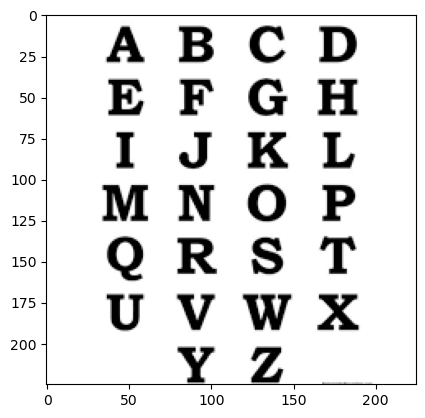

In [220]:
plt.imshow(img)

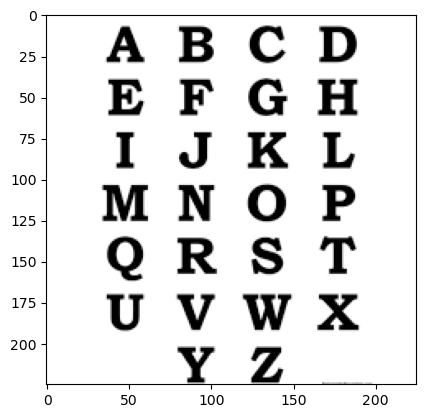

In [221]:
plt.imshow(gray, cmap='gray')

In [222]:
mser = cv2.MSER_create()
mser.setMinArea(100)

Number of regions: 408
Number of boxes: 408
Number of unique boxes: 130


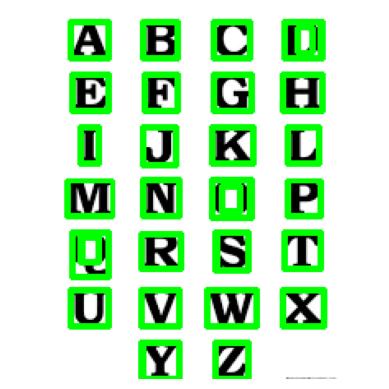

In [223]:
plt.axis('off')
regions, boxes = mser.detectRegions(gray)
unique_boxes = set(tuple(b) for b in boxes)
unique_boxes = [list(b) for b in unique_boxes]
print(f"Number of regions: {len(regions)}")
print(f"Number of boxes: {len(boxes)}")
print(f"Number of unique boxes: {len(unique_boxes)}")
img_copy = img.copy()
for i in range(len(unique_boxes)):
    x, y, w, h = unique_boxes[i]
    cv2.rectangle(img_copy, (x, y), (x + w, y + h), (0, 255, 0), 2)
plt.imshow(img_copy)
plt.show()


In [224]:
IMG_SIZE = 128
def calc_gradients(image):
    Gx = np.array([[-1, 0, 1]], dtype=np.float32)
    Gy = np.array([[-1], [0], [1]], dtype=np.float32)

    image = image.astype(np.float32)

    gx = cv2.filter2D(image, -1, Gx)
    gy = cv2.filter2D(image, -1, Gy)
    
    gradients_magnitude = np.sqrt(gx**2 + gy**2)
    gradients_orientation = (np.arctan2(gy, gx) * 180 / np.pi) % 180

    return gradients_magnitude, gradients_orientation


def HoG(orientations, magnitudes, cell_size=16, num_bins=9, block_size=2):
    bin_size = 180 / num_bins

    h, w = orientations.shape
    cells_y = h // cell_size
    cells_x = w // cell_size

    histograms = np.zeros((cells_y, cells_x, num_bins), dtype=np.float32)
    
    for cy in range(cells_y):
        for cx in range(cells_x):
            y0 = cy * cell_size
            x0 = cx * cell_size

            for y in range(cell_size):
                for x in range(cell_size):
                    angle = orientations[y0 + y, x0 + x]
                    mag = magnitudes[y0 + y, x0 + x]

                    bin_idx = int(angle / bin_size) % num_bins
                    histograms[cy, cx, bin_idx] += mag
                    
    features = []

    for y in range(cells_y - 1):
        for x in range(cells_x - 1):
            block = histograms[y:y+block_size, x:x+block_size].flatten()

            norm = np.linalg.norm(block)
            block = block / (norm + 1e-6)

            features.extend(block)

    return np.array(features, dtype=np.float32)

In [225]:

def predict(image, model=model, le=label_encoder):
    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
    image = image.astype(np.float32) / 255.0
    magnitudes, orientations = calc_gradients(image)
    # test_features = HoG(orientations, magnitudes, cell_size=16, num_bins=9, block_size=2).reshape(1, -1)
    magnitudes, orientations = calc_gradients(image)
    test_features = HoG(orientations, magnitudes, cell_size=16, num_bins=9, block_size=2).reshape(1, -1)
    predicted_label = model.predict(test_features)
    scores = model.decision_function(test_features)
    return predicted_label, scores

Predicted label for test image: e


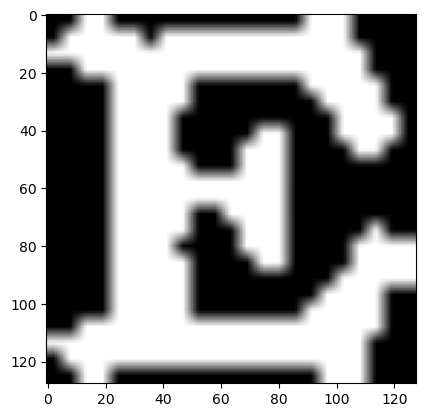

In [226]:
unique_boxes = sorted(unique_boxes, key=lambda b: (b[1], b[0]))
x, y, w, h = unique_boxes[24]
roi = gray[y:y+h, x:x+w]
roi = cv2.GaussianBlur(roi, (5, 5), 0)
binary_roi = cv2.adaptiveThreshold(roi, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 2)
roi_resized = cv2.resize(binary_roi, (IMG_SIZE, IMG_SIZE))
predicted_label, scores = predict(roi_resized)
print("Predicted label for test image:", label_encoder.inverse_transform(predicted_label)[0])
plt.imshow(roi_resized, cmap='gray')
softmax_scores = np.exp(scores) / np.sum(np.exp(scores))

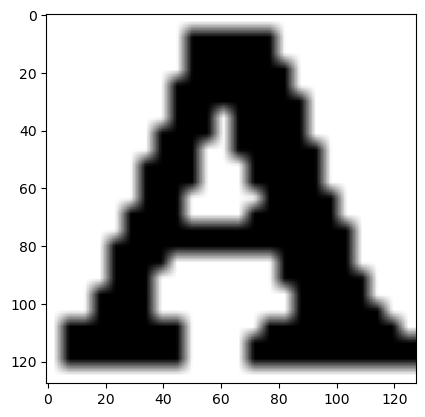

Predicted label for test image: g
0


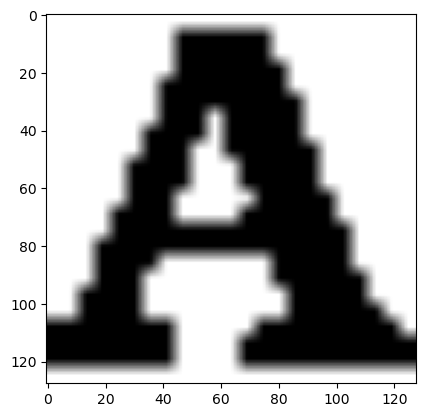

Predicted label for test image: g
1


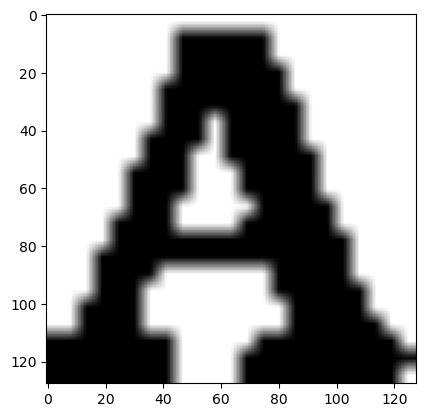

Predicted label for test image: A
2


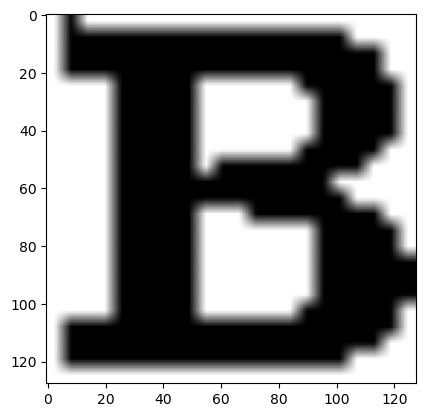

Predicted label for test image: E
3


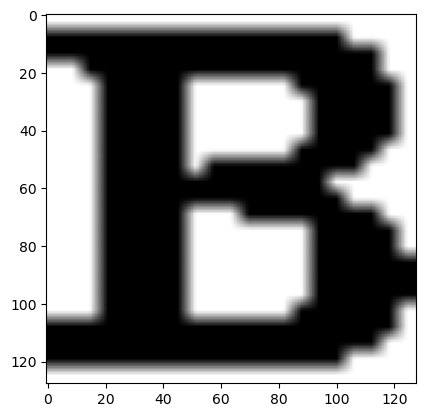

Predicted label for test image: E
4


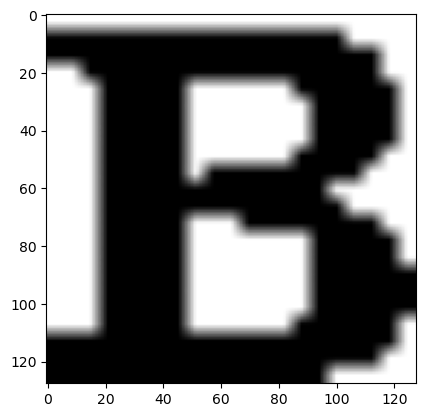

Predicted label for test image: B
5


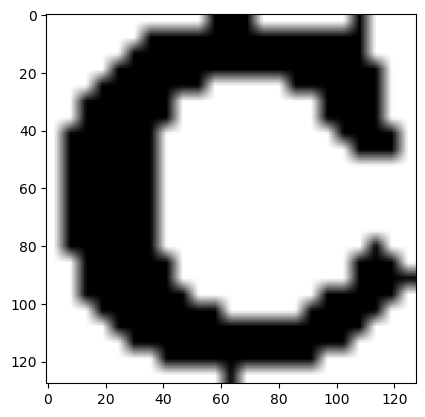

Predicted label for test image: C
6


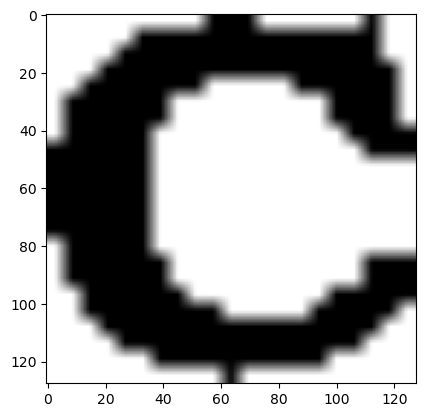

Predicted label for test image: C
7


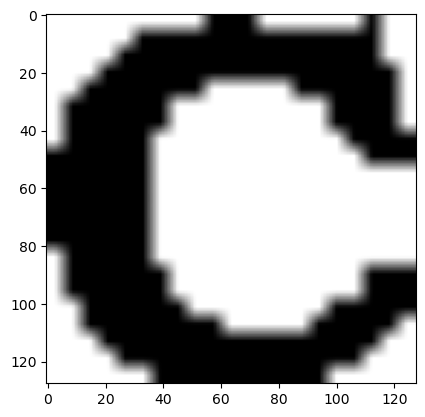

Predicted label for test image: C
8


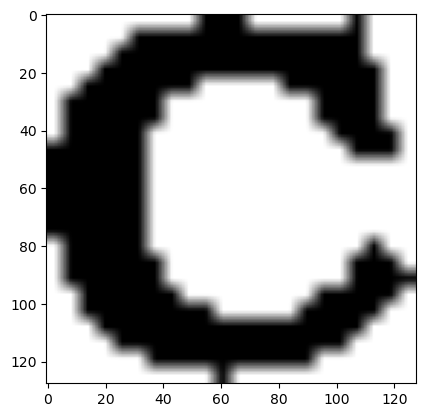

Predicted label for test image: C
9


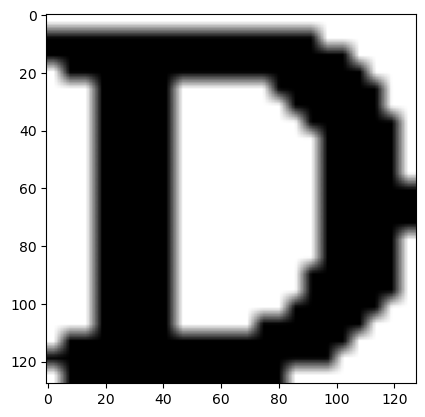

Predicted label for test image: Q
10


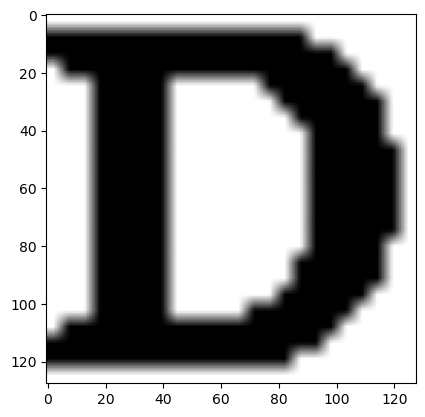

Predicted label for test image: 0
11


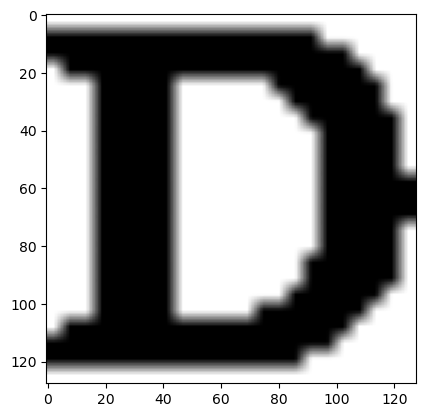

Predicted label for test image: Q
12


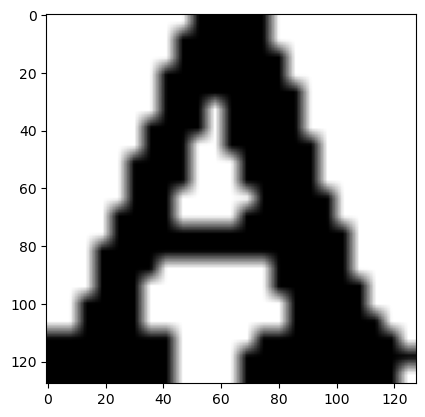

Predicted label for test image: A
13


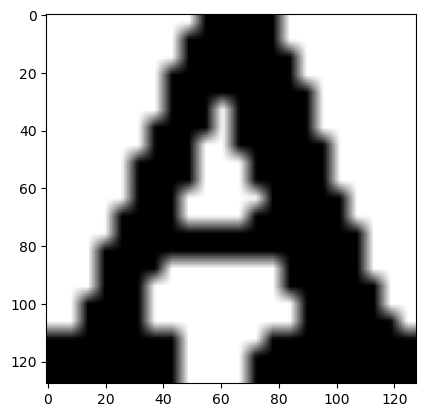

Predicted label for test image: A
14


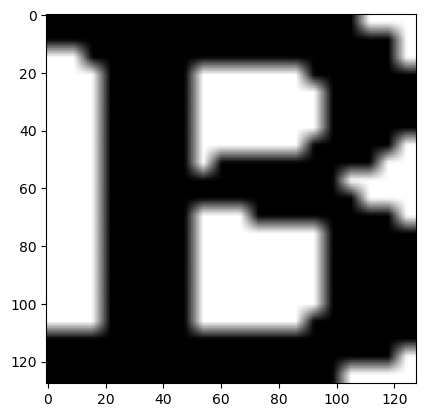

Predicted label for test image: B
15


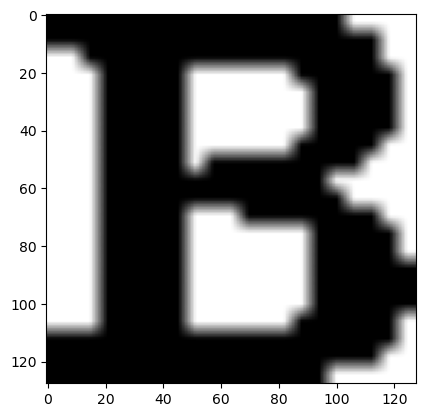

Predicted label for test image: B
16


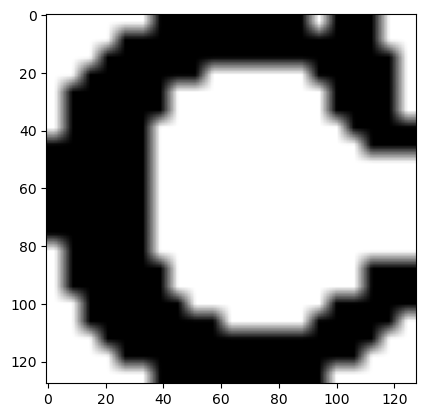

Predicted label for test image: C
17


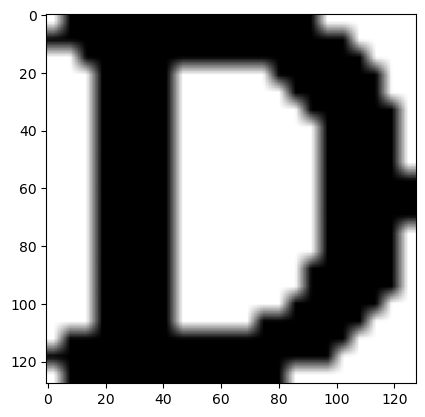

Predicted label for test image: M
18


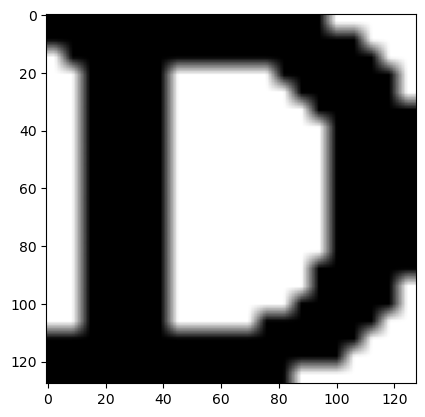

Predicted label for test image: D
19


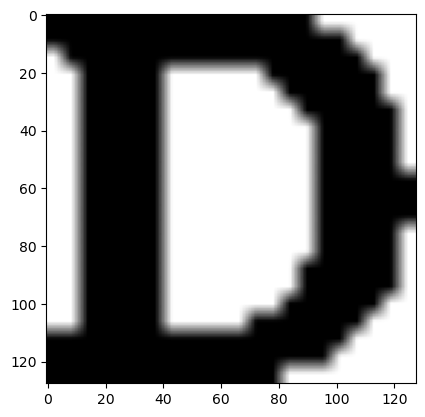

Predicted label for test image: D
20


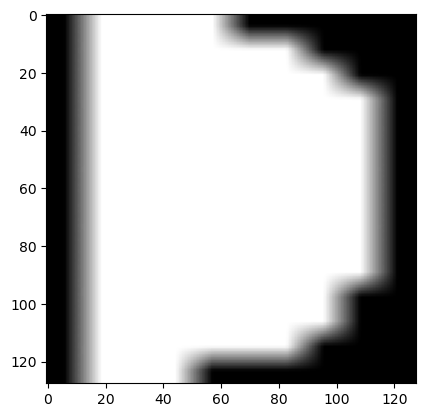

Predicted label for test image: n
21


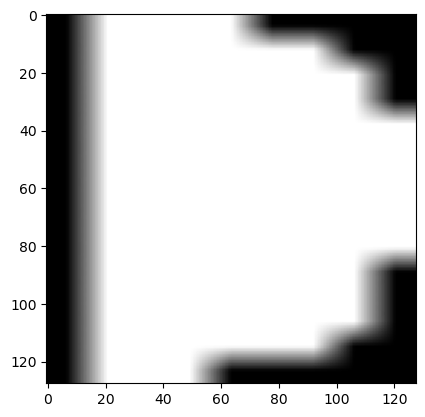

Predicted label for test image: C
22


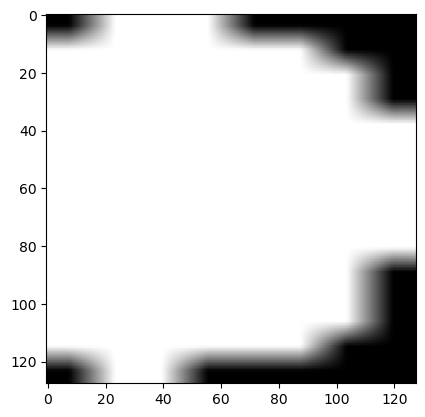

Predicted label for test image: L
23


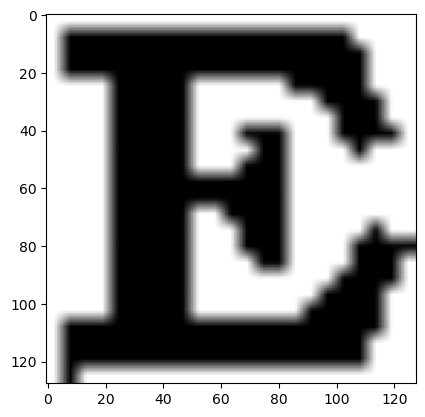

Predicted label for test image: E
24


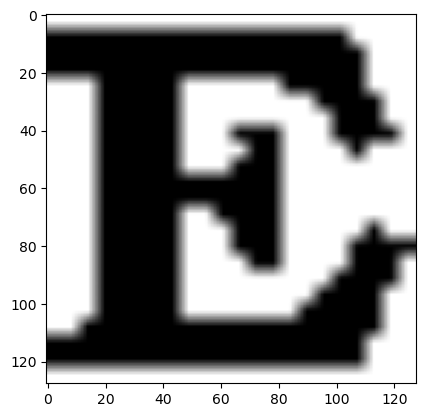

Predicted label for test image: E
25


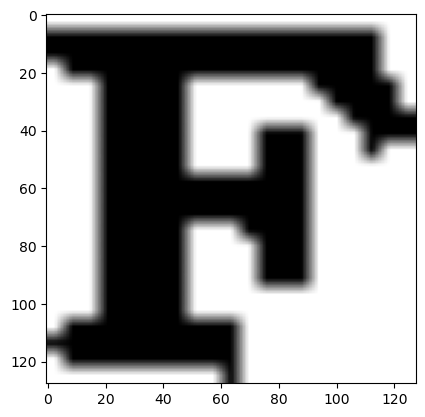

Predicted label for test image: F
26


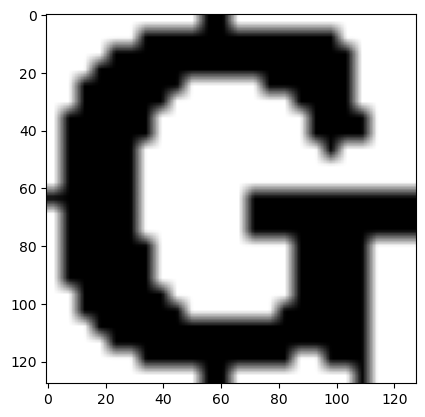

Predicted label for test image: G
27


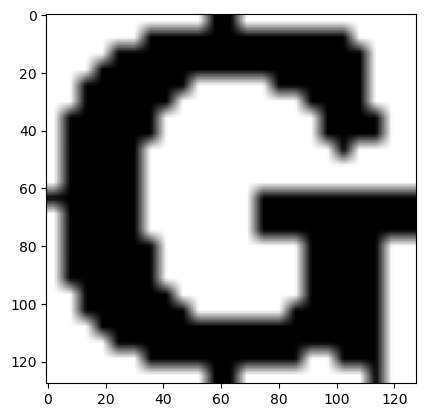

Predicted label for test image: G
28


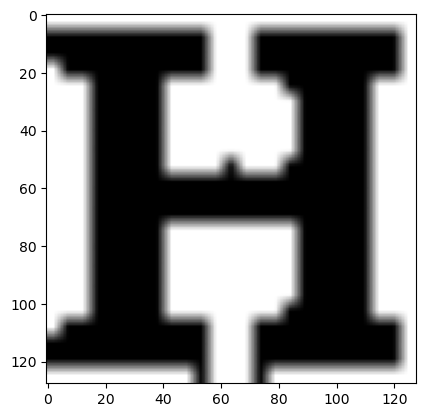

Predicted label for test image: A
29


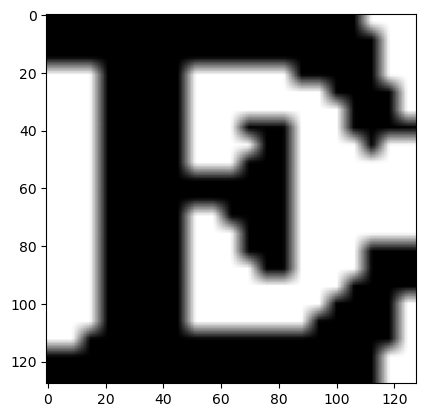

Predicted label for test image: E
30


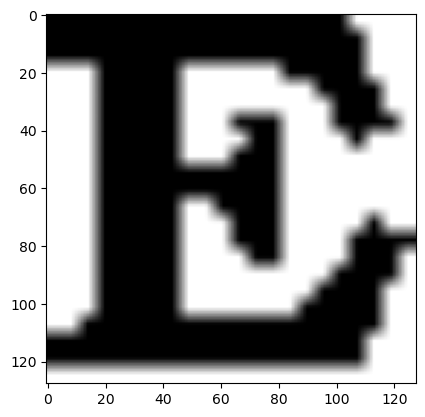

Predicted label for test image: E
31


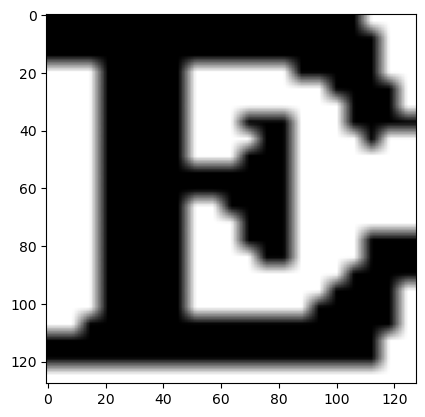

Predicted label for test image: E
32


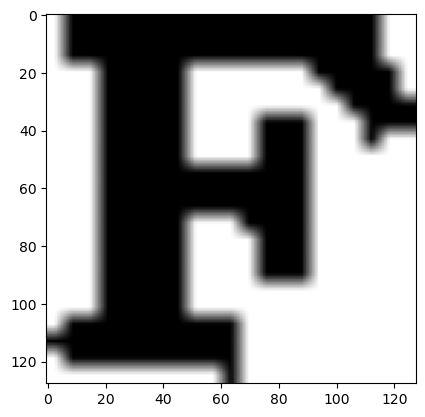

Predicted label for test image: F
33


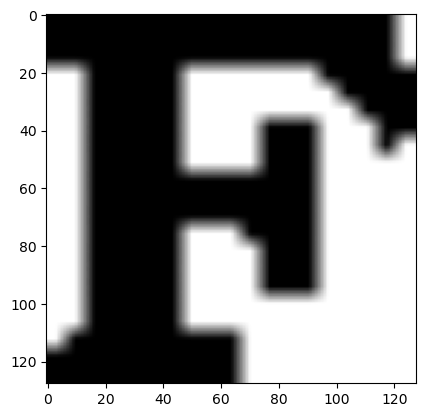

Predicted label for test image: a
34


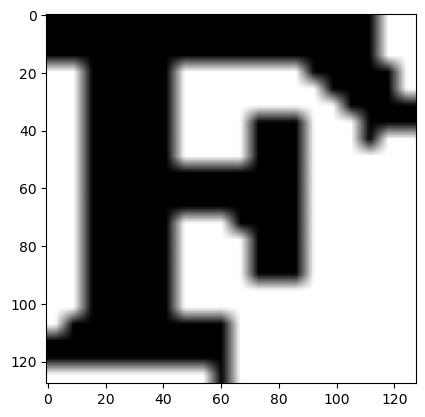

Predicted label for test image: Q
35


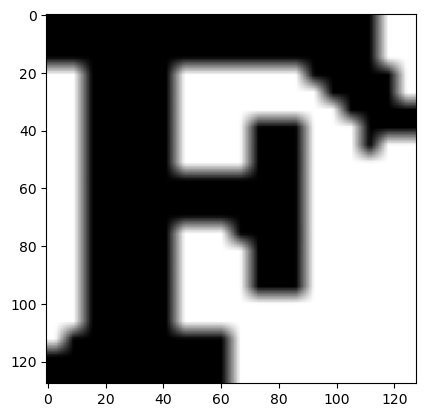

Predicted label for test image: D
36


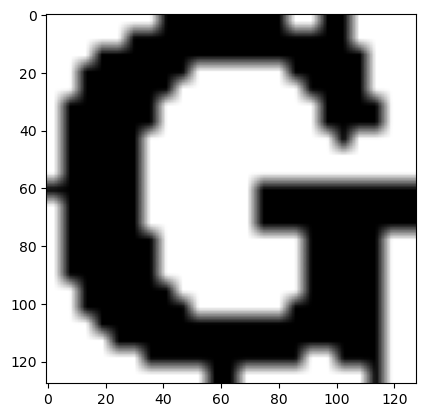

Predicted label for test image: C
37


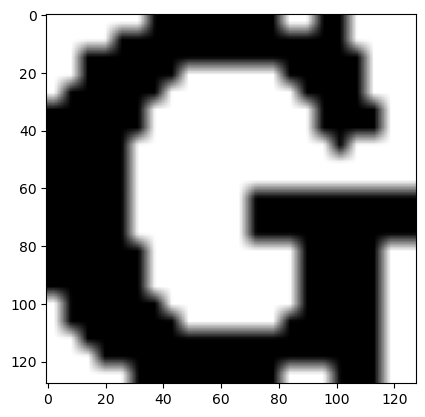

Predicted label for test image: E
38


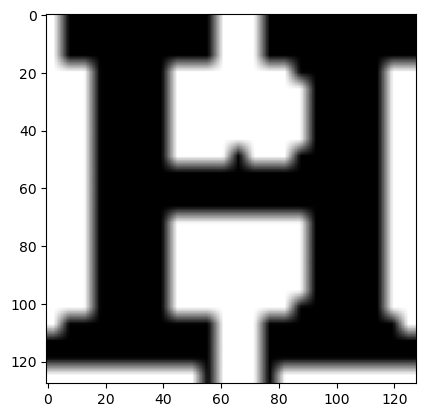

Predicted label for test image: A
39


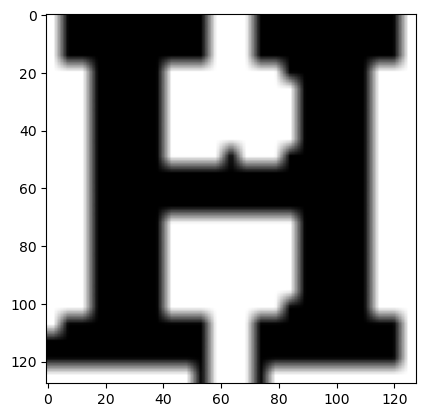

Predicted label for test image: A
40


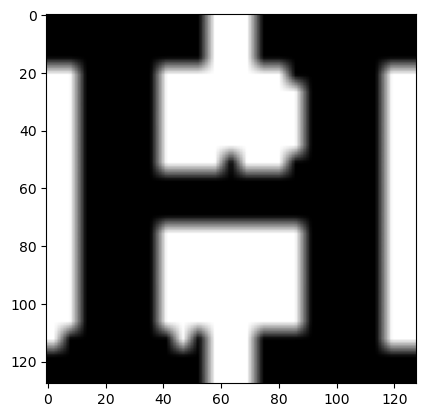

Predicted label for test image: A
41


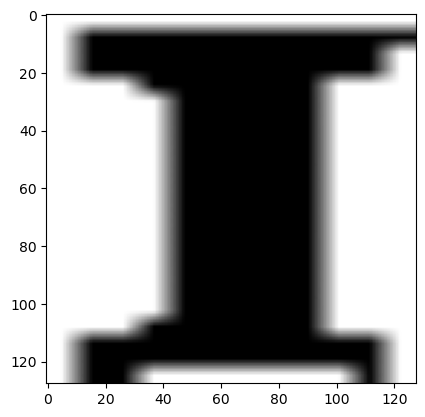

Predicted label for test image: H
42


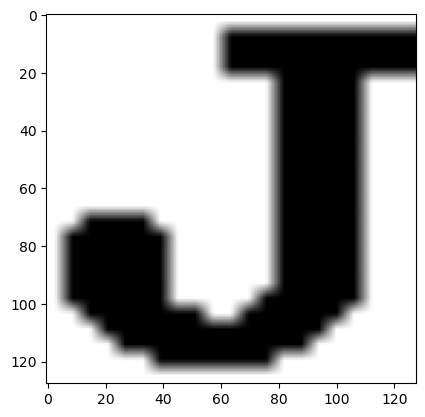

Predicted label for test image: J
43


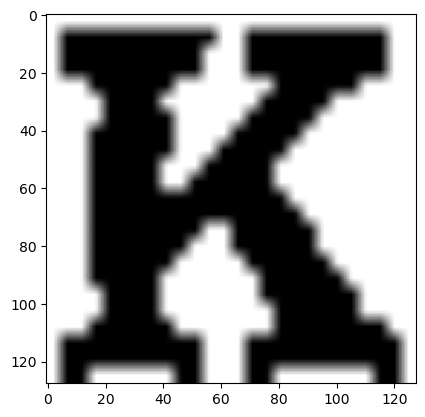

Predicted label for test image: K
44


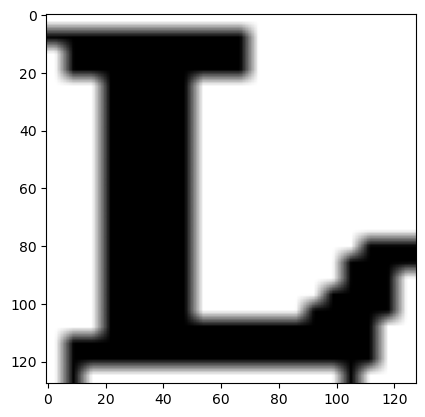

Predicted label for test image: L
45


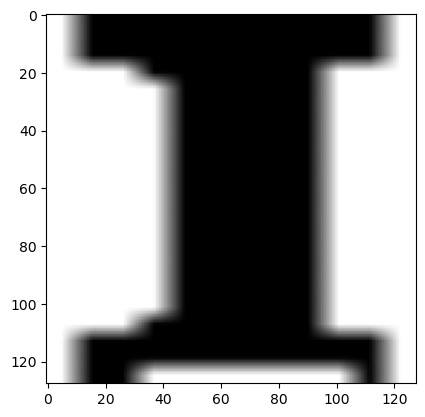

Predicted label for test image: H
46


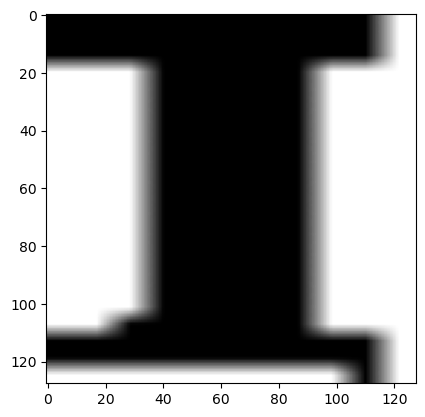

Predicted label for test image: E
47


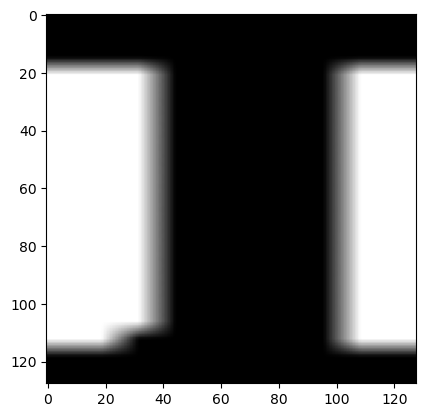

Predicted label for test image: n
48


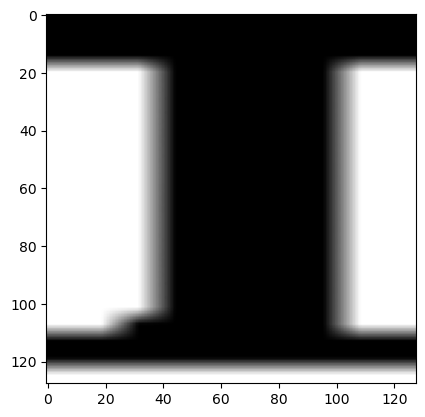

Predicted label for test image: L
49


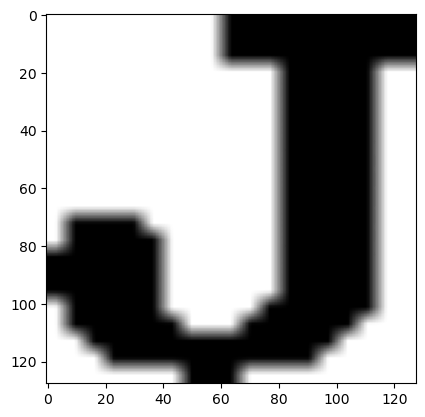

Predicted label for test image: L
50


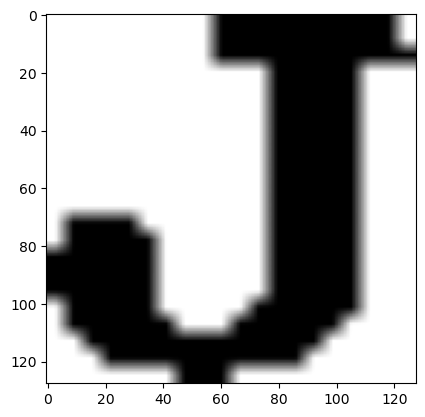

Predicted label for test image: J
51


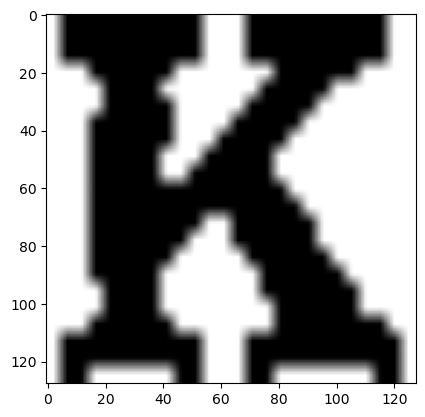

Predicted label for test image: K
52


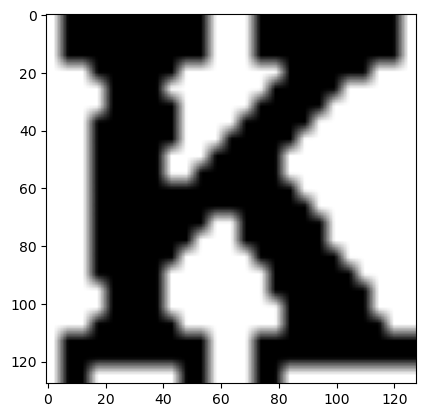

Predicted label for test image: K
53


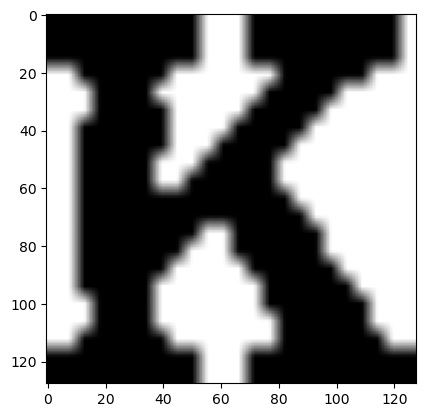

Predicted label for test image: K
54


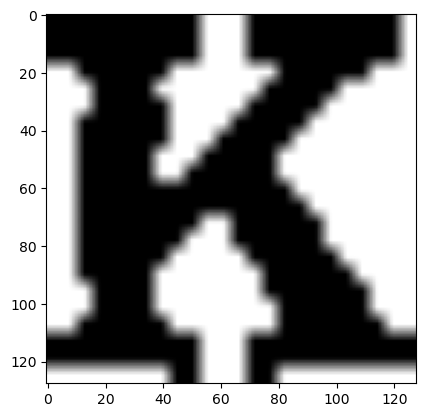

Predicted label for test image: K
55


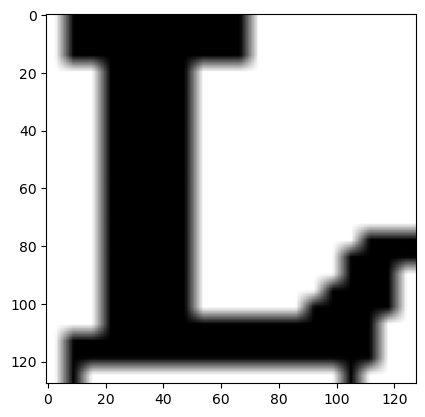

Predicted label for test image: L
56


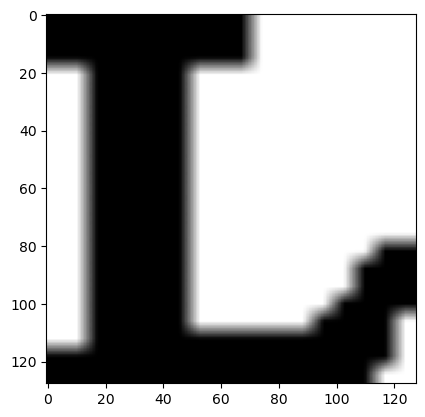

Predicted label for test image: L
57


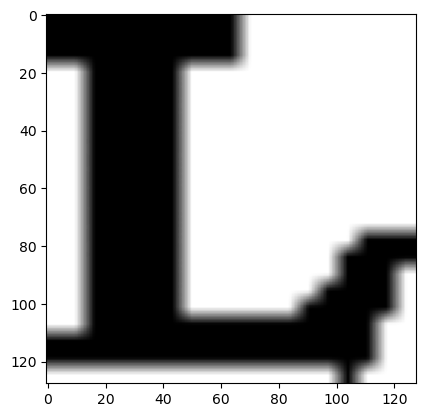

Predicted label for test image: L
58


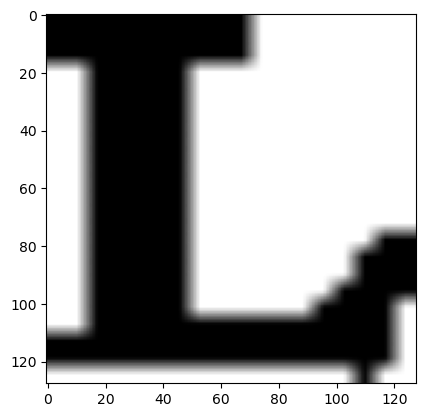

Predicted label for test image: L
59


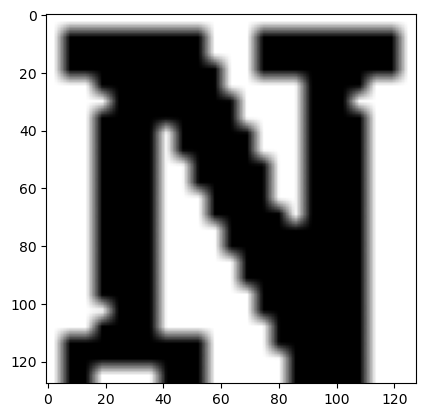

Predicted label for test image: N
60


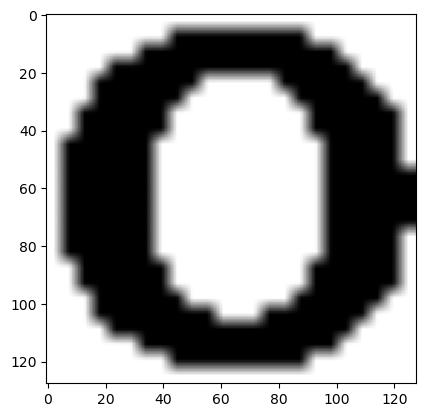

Predicted label for test image: 0
61


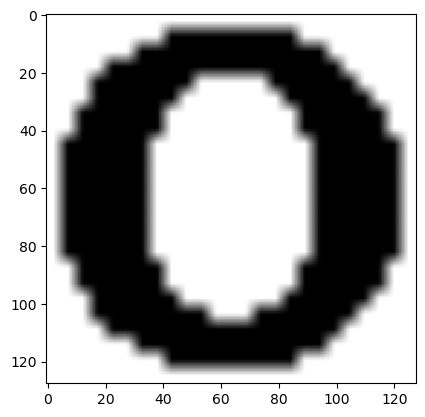

Predicted label for test image: 0
62


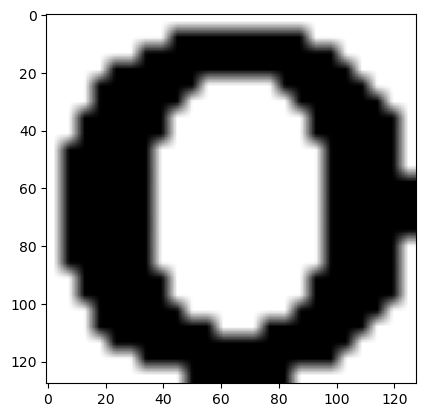

Predicted label for test image: Q
63


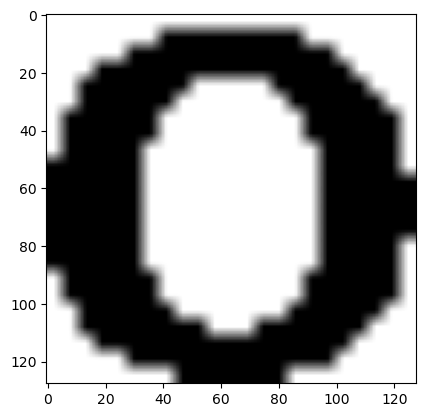

In [ ]:
unique_boxes = sorted(unique_boxes, key=lambda b: (b[1], b[0]))
i = 0
for box in unique_boxes:
    x, y, w, h = box
    roi = gray[y:y+h, x:x+w]
    # roi = cv2.GaussianBlur(roi, (9, 9), 0)
    binary_roi = cv2.adaptiveThreshold(roi, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)
    roi_resized = cv2.resize(binary_roi, (128, 128))
    plt.imshow(roi_resized, cmap='gray')
    plt.show()
    predicted_label, scores = predict(roi_resized)
    # if(scores[0][predicted_label[0]] > 0.5):
    #     text += label_encoder.inverse_transform(predicted_label)[0]
    print("Predicted label for test image:", label_encoder.inverse_transform(predicted_label)[0])
    print(i)
    i += 1
    

In [228]:
toLower = text.lower()
print(toLower)